# Compare Untouched and Retrained SBERT

This notebook loads the two saved SBERT encoders and their tuned One-vs-Rest classifiers, evaluates both on the same untouched test split, and saves a comparison report.

Run `sbert_training.ipynb` and `sbert_ovr.ipynb` first.


In [1]:
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    f1_score,
    hamming_loss,
    multilabel_confusion_matrix,
)
from sentence_transformers import SentenceTransformer


d:\ZB\Code\UIT\CS221\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = Path.cwd().resolve()
for _ in range(8):
    if (path / "data" / "Restaurant_ABSA_processed.csv").exists():
        PROJECT_ROOT = path
        break
    path = path.parent
else:
    raise FileNotFoundError("Could not locate the project root")

DATA_PATH = PROJECT_ROOT / "data" / "Restaurant_ABSA_processed.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "SBERT"
MODEL_DIR = PROJECT_ROOT / "models" / "sbert"
SPLIT_PATH = OUTPUT_DIR / "data_split.npz"
CLASSIFIER_ROOT = MODEL_DIR / "classifiers"
ENCODER_NAMES = ["unretrained", "retrained"]

required_paths = [DATA_PATH, SPLIT_PATH]
for encoder_name in ENCODER_NAMES:
    required_paths.extend([
        CLASSIFIER_ROOT / encoder_name / "model.joblib",
        CLASSIFIER_ROOT / encoder_name / "metadata.json",
    ])
for required_path in required_paths:
    if not required_path.exists():
        raise FileNotFoundError(f"Missing artifact: {required_path}")


In [3]:
df = pd.read_csv(DATA_PATH).dropna(subset=["review_en"]).reset_index(drop=True)
split = np.load(SPLIT_PATH)
test_idx = split["test_idx"]

test_texts = df.loc[test_idx, "review_en"].astype(str).tolist()
y_test = df.loc[
    test_idx,
    ["food", "price", "service", "ambiance", "miscellaneous"],
].to_numpy(dtype=np.int8)

print("Test samples:", len(test_texts))


Test samples: 160


In [4]:
def apply_thresholds(probabilities, thresholds, aspect_cols):
    predictions = np.zeros_like(probabilities, dtype=np.int8)
    for index, aspect in enumerate(aspect_cols):
        predictions[:, index] = (
            probabilities[:, index] >= thresholds[aspect]
        ).astype(np.int8)

    empty_rows = np.flatnonzero(predictions.sum(axis=1) == 0)
    for row in empty_rows:
        predictions[row, np.argmax(probabilities[row])] = 1
    return predictions


def evaluate_bundle(encoder_name):
    bundle_dir = CLASSIFIER_ROOT / encoder_name
    classifier = joblib.load(bundle_dir / "model.joblib")
    with (bundle_dir / "metadata.json").open(
        encoding="utf-8",
    ) as file:
        metadata = json.load(file)

    encoder_path = PROJECT_ROOT / metadata["encoder_path"]
    encoder = SentenceTransformer(str(encoder_path))

    start = time.perf_counter()
    embeddings = encoder.encode(
        test_texts,
        batch_size=metadata["batch_size"],
        normalize_embeddings=metadata["normalize_embeddings"],
        convert_to_numpy=True,
        show_progress_bar=True,
    )
    probabilities = classifier.predict_proba(embeddings)
    elapsed = time.perf_counter() - start

    predictions = apply_thresholds(
        probabilities,
        metadata["thresholds"],
        metadata["aspect_cols"],
    )
    per_class_f1 = f1_score(
        y_test,
        predictions,
        average=None,
        zero_division=0,
    )

    metrics = {
        "encoder": encoder_name,
        "macro_f1": f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "micro_f1": f1_score(
            y_test,
            predictions,
            average="micro",
            zero_division=0,
        ),
        "samples_f1": f1_score(
            y_test,
            predictions,
            average="samples",
            zero_division=0,
        ),
        "hamming_loss": hamming_loss(y_test, predictions),
        "seconds": elapsed,
        "milliseconds_per_review": elapsed * 1000 / len(test_texts),
    }
    for index, aspect in enumerate(metadata["aspect_cols"]):
        metrics[f"{aspect}_f1"] = per_class_f1[index]

    return {
        "metadata": metadata,
        "metrics": metrics,
        "probabilities": probabilities,
        "predictions": predictions,
        "report": classification_report(
            y_test,
            predictions,
            target_names=metadata["aspect_cols"],
            output_dict=True,
            zero_division=0,
        ),
    }


In [5]:
evaluations = {
    encoder_name: evaluate_bundle(encoder_name)
    for encoder_name in ENCODER_NAMES
}

comparison_df = (
    pd.DataFrame([
        result["metrics"]
        for result in evaluations.values()
    ])
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

comparison_df.to_csv(
    OUTPUT_DIR / "encoder_comparison.csv",
    index=False,
)
comparison_df


Batches: 100%|██████████| 5/5 [00:05<00:00,  1.07s/it]


,encoder,macro_f1,micro_f1,samples_f1,hamming_loss,seconds,milliseconds_per_review,food_f1,price_f1,service_f1,ambiance_f1,miscellaneous_f1
0,retrained,0.829627,0.923077,0.921458,0.06125,5.368480,33.553000,0.965251,0.987342,0.957447,0.952381,0.285714
1,unretrained,0.783676,0.878505,0.878958,0.09750,5.772086,36.075535,0.956863,0.967742,0.926316,0.888889,0.178571


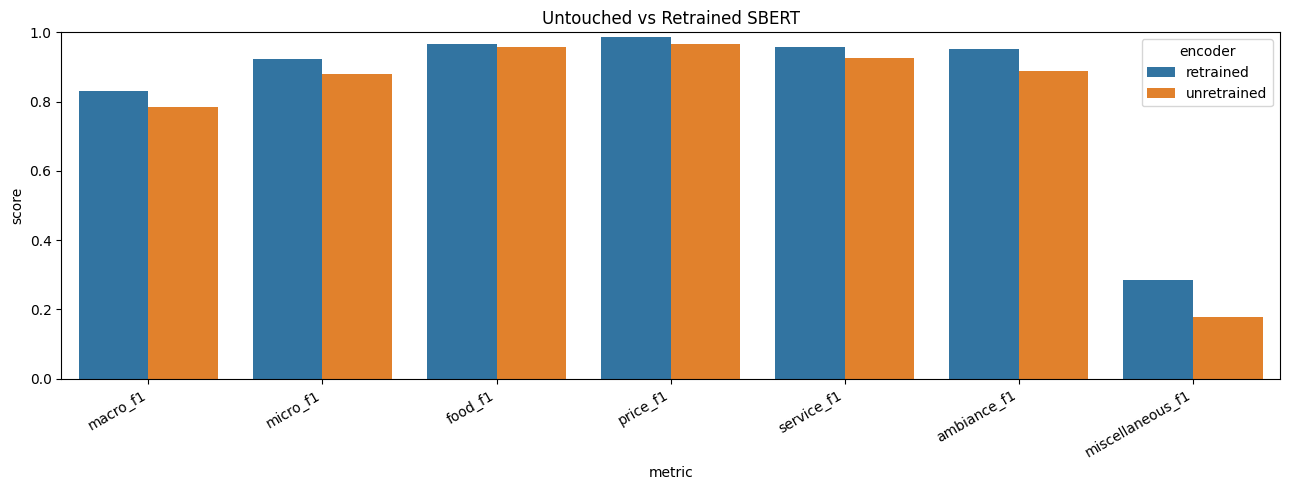

In [6]:
metric_columns = [
    "macro_f1",
    "micro_f1",
    "food_f1",
    "price_f1",
    "service_f1",
    "ambiance_f1",
    "miscellaneous_f1",
]

plot_df = comparison_df.melt(
    id_vars="encoder",
    value_vars=metric_columns,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(13, 5))
sns.barplot(
    data=plot_df,
    x="metric",
    y="score",
    hue="encoder",
)
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.title("Untouched vs Retrained SBERT")
plt.tight_layout()
plt.show()



===== UNRETRAINED =====


,precision,recall,f1-score,support
food,0.938462,0.976000,0.956863,125.0
price,0.974026,0.961538,0.967742,78.0
service,0.936170,0.916667,0.926316,48.0
ambiance,0.972973,0.818182,0.888889,44.0
miscellaneous,0.116279,0.384615,0.178571,13.0
micro avg,0.844311,0.915584,0.878505,308.0
macro avg,0.787582,0.811400,0.783676,308.0
weighted avg,0.917339,0.915584,0.912297,308.0
samples avg,0.865625,0.919792,0.878958,308.0


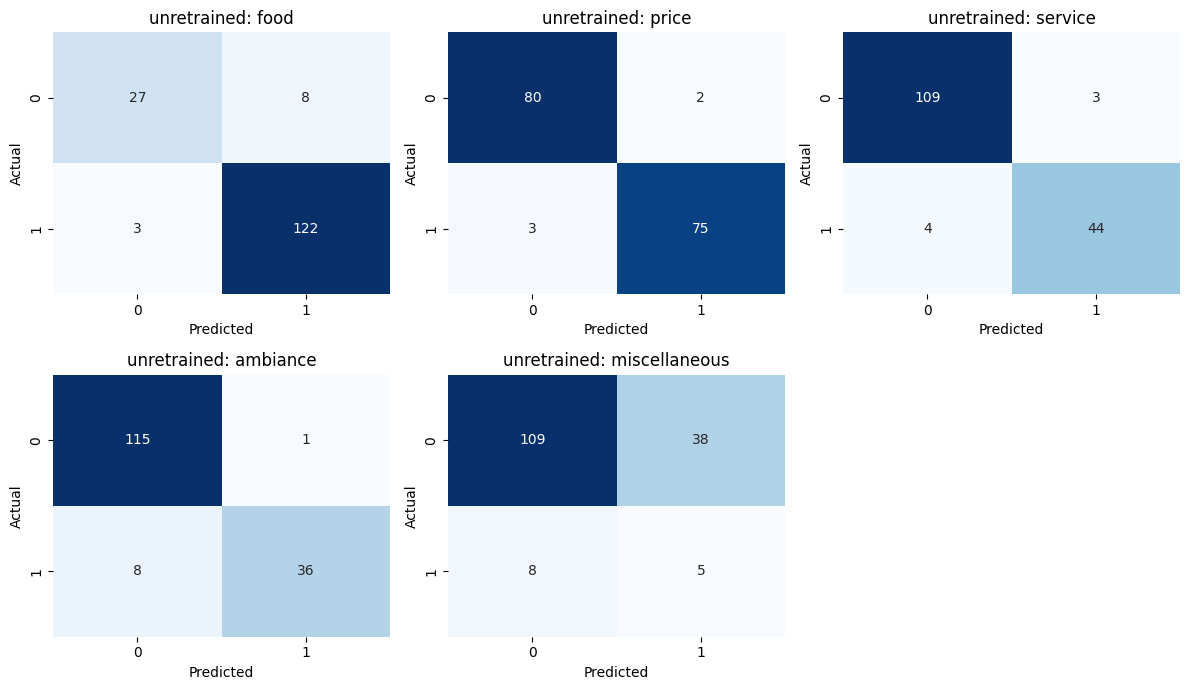


===== RETRAINED =====


,precision,recall,f1-score,support
food,0.932836,1.000000,0.965251,125.0
price,0.975000,1.000000,0.987342,78.0
service,0.978261,0.937500,0.957447,48.0
ambiance,1.000000,0.909091,0.952381,44.0
miscellaneous,0.206897,0.461538,0.285714,13.0
micro avg,0.893617,0.954545,0.923077,308.0
macro avg,0.818599,0.861626,0.829627,308.0
weighted avg,0.929548,0.954545,0.939109,308.0
samples avg,0.908333,0.956250,0.921458,308.0


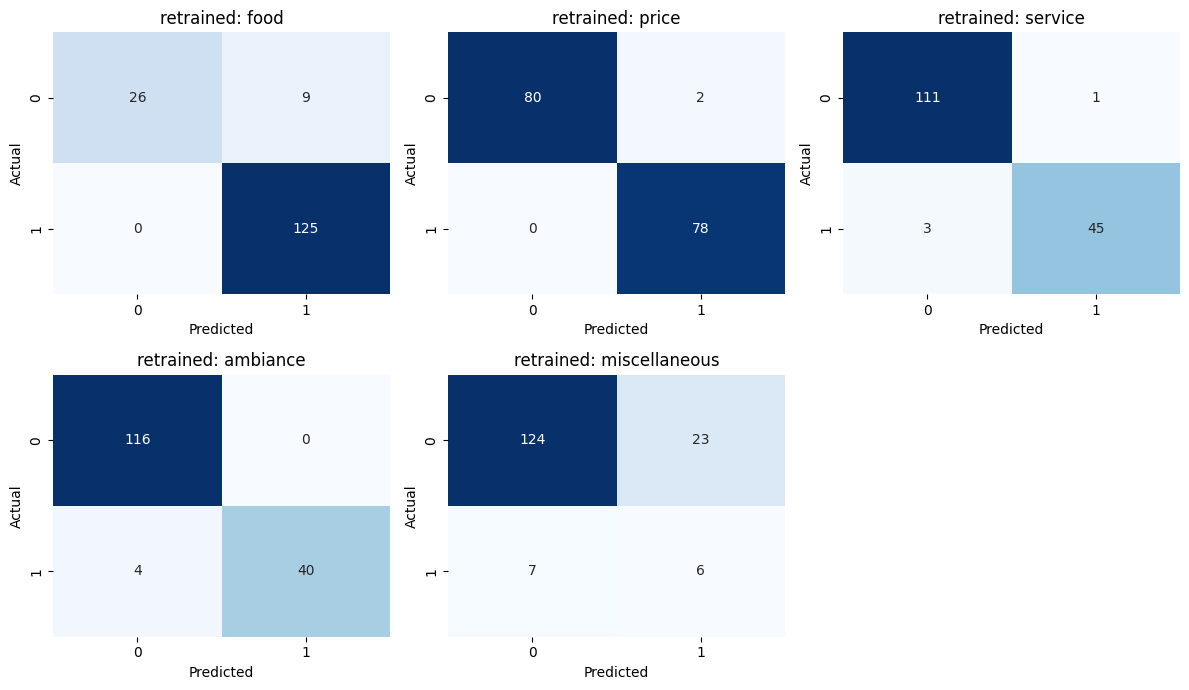

In [7]:
for encoder_name, result in evaluations.items():
    print(f"\n===== {encoder_name.upper()} =====")
    report_df = pd.DataFrame(result["report"]).T
    display(report_df)
    report_df.to_csv(
        OUTPUT_DIR / f"{encoder_name}_classification_report.csv"
    )

    matrices = multilabel_confusion_matrix(
        y_test,
        result["predictions"],
    )
    aspect_cols = result["metadata"]["aspect_cols"]

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    for index, aspect in enumerate(aspect_cols):
        sns.heatmap(
            matrices[index],
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=axes.flat[index],
        )
        axes.flat[index].set_title(f"{encoder_name}: {aspect}")
        axes.flat[index].set_xlabel("Predicted")
        axes.flat[index].set_ylabel("Actual")
    axes.flat[-1].axis("off")
    plt.tight_layout()
    plt.show()


## Retrained-model sample analysis

The following cells inspect exact-match predictions from the retrained encoder, display representative correct and incorrect reviews, and rank the clearest best and worst cases. The ranking is diagnostic only and does not change the model or thresholds.


In [ ]:
RETRAINED_NAME = "retrained"
retrained_result = evaluations[RETRAINED_NAME]
retrained_metadata = retrained_result["metadata"]
retrained_probabilities = retrained_result["probabilities"]
retrained_predictions = retrained_result["predictions"]
retrained_aspects = retrained_metadata["aspect_cols"]


def labels_from_row(binary_row, aspect_cols):
    return [
        aspect
        for index, aspect in enumerate(aspect_cols)
        if binary_row[index] == 1
    ]


sample_rows = []
for row, review in enumerate(test_texts):
    true_row = y_test[row]
    predicted_row = retrained_predictions[row]
    probabilities_row = retrained_probabilities[row]

    true_positive_count = int(
        np.logical_and(true_row == 1, predicted_row == 1).sum()
    )
    false_positive_count = int(
        np.logical_and(true_row == 0, predicted_row == 1).sum()
    )
    false_negative_count = int(
        np.logical_and(true_row == 1, predicted_row == 0).sum()
    )
    denominator = (
        2 * true_positive_count
        + false_positive_count
        + false_negative_count
    )
    sample_f1 = (
        2 * true_positive_count / denominator
        if denominator
        else 1.0
    )

    false_positives = [
        retrained_aspects[index]
        for index in range(len(retrained_aspects))
        if true_row[index] == 0 and predicted_row[index] == 1
    ]
    false_negatives = [
        retrained_aspects[index]
        for index in range(len(retrained_aspects))
        if true_row[index] == 1 and predicted_row[index] == 0
    ]

    predicted_indices = np.flatnonzero(predicted_row)
    predicted_confidence = (
        float(probabilities_row[predicted_indices].mean())
        if len(predicted_indices)
        else 0.0
    )
    wrong_confidences = [
        float(probabilities_row[index])
        for index in range(len(retrained_aspects))
        if (
            true_row[index] != predicted_row[index]
        )
    ]

    sample_rows.append({
        "test_row": row,
        "dataset_index": int(test_idx[row]),
        "review": review,
        "true_labels": labels_from_row(true_row, retrained_aspects),
        "predicted_labels": labels_from_row(
            predicted_row,
            retrained_aspects,
        ),
        "exact_match": bool(np.array_equal(true_row, predicted_row)),
        "sample_f1": sample_f1,
        "error_count": false_positive_count + false_negative_count,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "predicted_confidence": predicted_confidence,
        "maximum_wrong_confidence": (
            max(wrong_confidences)
            if wrong_confidences
            else 0.0
        ),
        **{
            f"prob_{aspect}": float(probabilities_row[index])
            for index, aspect in enumerate(retrained_aspects)
        },
    })

retrained_samples_df = pd.DataFrame(sample_rows)

print(
    "Exact matches:",
    int(retrained_samples_df["exact_match"].sum()),
    "/",
    len(retrained_samples_df),
)
print(
    "Incorrect samples:",
    int((~retrained_samples_df["exact_match"]).sum()),
)


### Correct and incorrect samples

Correct samples are exact label-set matches. Incorrect samples include at least one missing or extra aspect.


In [ ]:
DISPLAY_COLUMNS = [
    "dataset_index",
    "review",
    "true_labels",
    "predicted_labels",
    "sample_f1",
    "false_positives",
    "false_negatives",
    "predicted_confidence",
]

correct_samples = (
    retrained_samples_df[
        retrained_samples_df["exact_match"]
    ]
    .sort_values(
        "predicted_confidence",
        ascending=False,
    )
)

incorrect_samples = (
    retrained_samples_df[
        ~retrained_samples_df["exact_match"]
    ]
    .sort_values(
        ["sample_f1", "error_count", "maximum_wrong_confidence"],
        ascending=[True, False, False],
    )
)

print("High-confidence correct samples")
display(correct_samples[DISPLAY_COLUMNS].head(10))

print("Incorrect samples")
display(incorrect_samples[DISPLAY_COLUMNS].head(15))


### Best cases

Best cases are exact matches with the highest average probability across predicted labels. They show review patterns the retrained model recognizes most clearly.


In [ ]:
best_cases = correct_samples.head(10).copy()
display(
    best_cases[
        DISPLAY_COLUMNS
        + [f"prob_{aspect}" for aspect in retrained_aspects]
    ]
)

print("Most common true-label combinations among exact matches:")
display(
    correct_samples["true_labels"]
    .apply(lambda labels: " + ".join(labels))
    .value_counts()
    .rename_axis("label_combination")
    .reset_index(name="correct_samples")
    .head(10)
)


### Worst cases

Worst cases prioritize the lowest sample-level F1, then the largest number of label errors, then the highest confidence assigned to a wrong decision. These cases are useful for identifying label ambiguity, noisy translations, missing training patterns, and threshold problems.


In [ ]:
worst_cases = incorrect_samples.head(15).copy()
display(
    worst_cases[
        DISPLAY_COLUMNS
        + ["maximum_wrong_confidence"]
        + [f"prob_{aspect}" for aspect in retrained_aspects]
    ]
)

worst_cases.to_csv(
    OUTPUT_DIR / "retrained_worst_cases.csv",
    index=False,
)
correct_samples.head(25).to_csv(
    OUTPUT_DIR / "retrained_best_cases.csv",
    index=False,
)
retrained_samples_df.to_csv(
    OUTPUT_DIR / "retrained_sample_predictions.csv",
    index=False,
)


### Per-aspect error analysis

This table identifies whether each aspect mainly suffers from false positives or false negatives. High false positives suggest raising the threshold; high false negatives suggest lowering it or adding more representative training examples.


In [ ]:
aspect_error_rows = []

for index, aspect in enumerate(retrained_aspects):
    true_values = y_test[:, index]
    predicted_values = retrained_predictions[:, index]

    true_positives = int(
        np.logical_and(true_values == 1, predicted_values == 1).sum()
    )
    false_positives = int(
        np.logical_and(true_values == 0, predicted_values == 1).sum()
    )
    false_negatives = int(
        np.logical_and(true_values == 1, predicted_values == 0).sum()
    )
    true_negatives = int(
        np.logical_and(true_values == 0, predicted_values == 0).sum()
    )

    aspect_error_rows.append({
        "aspect": aspect,
        "threshold": retrained_metadata["thresholds"][aspect],
        "true_positives": true_positives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "true_negatives": true_negatives,
        "f1": f1_score(
            true_values,
            predicted_values,
            zero_division=0,
        ),
        "main_error_type": (
            "false positives"
            if false_positives > false_negatives
            else "false negatives"
            if false_negatives > false_positives
            else "balanced"
        ),
    })

aspect_error_df = (
    pd.DataFrame(aspect_error_rows)
    .sort_values("f1")
    .reset_index(drop=True)
)

aspect_error_df.to_csv(
    OUTPUT_DIR / "retrained_aspect_error_analysis.csv",
    index=False,
)
display(aspect_error_df)


In [ ]:
error_plot_df = aspect_error_df.melt(
    id_vars="aspect",
    value_vars=["false_positives", "false_negatives"],
    var_name="error_type",
    value_name="count",
)

plt.figure(figsize=(9, 4))
sns.barplot(
    data=error_plot_df,
    x="aspect",
    y="count",
    hue="error_type",
)
plt.title("Retrained SBERT errors by aspect")
plt.ylabel("Test samples")
plt.xlabel("Aspect")
plt.tight_layout()
plt.show()
